In [59]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import *
# from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from matplotlib import pyplot as plt
from sklearn import metrics
import seaborn as sns
import pickle

In [60]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models


In [61]:
tf.__version__

'2.16.1'

In [62]:
df=pd.read_csv('diabetes_data_upload.csv')
visual=df.copy()
visual

,Age,Gender,Polyuria,Polydipsia,sudden weight loss,weakness,Polyphagia,Genital thrush,visual blurring,Itching,Irritability,delayed healing,partial paresis,muscle stiffness,Alopecia,Obesity,class
0,40,Male,No,Yes,No,Yes,No,No,No,Yes,No,Yes,No,Yes,Yes,Yes,Positive
1,58,Male,No,No,No,Yes,No,No,Yes,No,No,No,Yes,No,Yes,No,Positive
2,41,Male,Yes,No,No,Yes,Yes,No,No,Yes,No,Yes,No,Yes,Yes,No,Positive
3,45,Male,No,No,Yes,Yes,Yes,Yes,No,Yes,No,Yes,No,No,No,No,Positive
4,60,Male,Yes,Yes,Yes,Yes,Yes,No,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Positive
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
515,39,Female,Yes,Yes,Yes,No,Yes,No,No,Yes,No,Yes,Yes,No,No,No,Positive
516,48,Female,Yes,Yes,Yes,Yes,Yes,No,No,Yes,Yes,Yes,Yes,No,No,No,Positive
517,58,Female,Yes,Yes,Yes,Yes,Yes,No,Yes,No,No,No,Yes,Yes,No,Yes,Positive
518,32,Female,No,No,No,Yes,No,No,Yes,Yes,No,Yes,No,No,Yes,No,Negative


In [63]:
numerical_features = df.select_dtypes(include=[np.number]).columns
categorical_features = df.select_dtypes(include=['object']).columns

numerical_features, categorical_features

(Index(['Age'], dtype='object'),
 Index(['Gender', 'Polyuria', 'Polydipsia', 'sudden weight loss', 'weakness',
        'Polyphagia', 'Genital thrush', 'visual blurring', 'Itching',
        'Irritability', 'delayed healing', 'partial paresis',
        'muscle stiffness', 'Alopecia', 'Obesity', 'class'],
       dtype='object'))

In [64]:
ones=['Male','Positive','Yes']
for col in categorical_features:
    df[col] = df[col].apply(lambda x:  1 if x in ones else 0)

df

,Age,Gender,Polyuria,Polydipsia,sudden weight loss,weakness,Polyphagia,Genital thrush,visual blurring,Itching,Irritability,delayed healing,partial paresis,muscle stiffness,Alopecia,Obesity,class
0,40,1,0,1,0,1,0,0,0,1,0,1,0,1,1,1,1
1,58,1,0,0,0,1,0,0,1,0,0,0,1,0,1,0,1
2,41,1,1,0,0,1,1,0,0,1,0,1,0,1,1,0,1
3,45,1,0,0,1,1,1,1,0,1,0,1,0,0,0,0,1
4,60,1,1,1,1,1,1,0,1,1,1,1,1,1,1,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
515,39,0,1,1,1,0,1,0,0,1,0,1,1,0,0,0,1
516,48,0,1,1,1,1,1,0,0,1,1,1,1,0,0,0,1
517,58,0,1,1,1,1,1,0,1,0,0,0,1,1,0,1,1
518,32,0,0,0,0,1,0,0,1,1,0,1,0,0,1,0,0


In [65]:
target = df['class']
df.drop('class', axis=1, inplace=True)

In [77]:
min_max_scaler = MinMaxScaler()

In [78]:
# normalized_df=(df-df.min())/(df.max()-df.min())
normalized_df=min_max_scaler.fit_transform(df)
X=pd.DataFrame(normalized_df, columns=df.columns)
X
    

,Age,Gender,Polyuria,Polydipsia,sudden weight loss,weakness,Polyphagia,Genital thrush,visual blurring,Itching,Irritability,delayed healing,partial paresis,muscle stiffness,Alopecia,Obesity
0,0.324324,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0,1.0
1,0.567568,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
2,0.337838,1.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0
3,0.391892,1.0,0.0,0.0,1.0,1.0,1.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0
4,0.594595,1.0,1.0,1.0,1.0,1.0,1.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
515,0.310811,0.0,1.0,1.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0
516,0.432432,0.0,1.0,1.0,1.0,1.0,1.0,0.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0
517,0.567568,0.0,1.0,1.0,1.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,1.0
518,0.216216,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0


In [79]:
with open('scaler.pkl', 'wb') as f:
    pickle.dump(min_max_scaler, f)

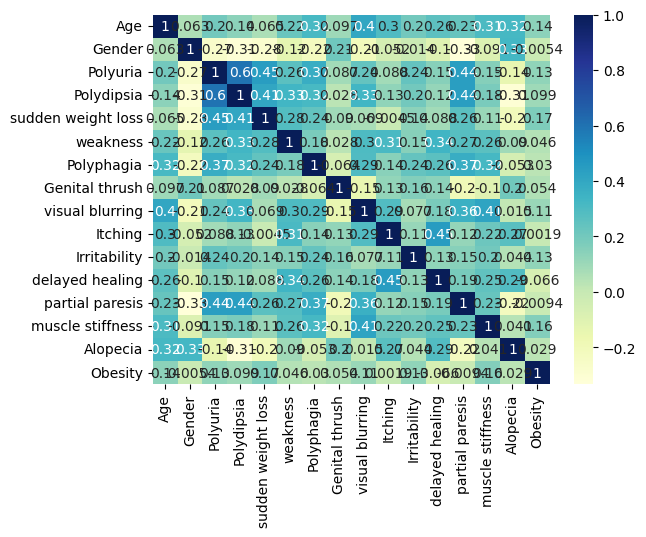

In [67]:
sns.heatmap(df.corr(), annot=True, cmap="YlGnBu");

In [68]:
#convert dataframes to tensorflows datasets
def df_to_dataset(dataframe, target, shuffle=True, batch_size=32):
    dataframe = dataframe.copy()
    labels = dataframe.pop(target)
    ds = tf.data.Dataset.from_tensor_slices((dict(dataframe), labels))
    if shuffle:
        ds = ds.shuffle(buffer_size=len(dataframe))
    ds = ds.batch(batch_size)
    return ds

In [69]:
x_train, x_test, y_train, y_test = train_test_split(X,target, test_size=0.1, random_state=42, shuffle=True)

In [70]:
model=keras.Sequential([
    layers.Input(shape=(df.shape[1],)),
    layers.Dense(64, activation='relu'),
    layers.Dense(64, activation='relu'),
    layers.Dense(1, activation='sigmoid')
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy','precision','recall','AUC'])
model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_9 (Dense)                 │ (None, 64)             │         1,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,313 (20.75 KB)

 Trainable params: 5,313 (20.75 KB)

 Non-trainable params: 0 (0.00 B)

In [71]:
batch_size=1
callbacks = [
    keras.callbacks.EarlyStopping(patience=10, verbose=1, restore_best_weights=True, monitor='val_loss'),
]

history= model.fit(x_train, y_train, epochs=100, batch_size=batch_size, validation_split=0.1, callbacks=callbacks)

Epoch 1/100
421/421 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - AUC: 0.8372 - accuracy: 0.7255 - loss: 0.4782 - precision: 0.7352 - recall: 0.9083 - val_AUC: 0.9958 - val_accuracy: 0.9787 - val_loss: 0.1466 - val_precision: 1.0000 - val_recall: 0.9688
Epoch 2/100
421/421 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - AUC: 0.9800 - accuracy: 0.9323 - loss: 0.1819 - precision: 0.9434 - recall: 0.9235 - val_AUC: 1.0000 - val_accuracy: 0.9787 - val_loss: 0.0906 - val_precision: 1.0000 - val_recall: 0.9688
Epoch 3/100
421/421 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - AUC: 0.9803 - accuracy: 0.9324 - loss: 0.1557 - precision: 0.9643 - recall: 0.9273 - val_AUC: 1.0000 - val_accuracy: 0.9787 - val_loss: 0.0545 - val_precision: 1.0000 - val_recall: 0.9688
Epoch 4/100
421/421 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - AUC: 0.9930 - accuracy: 0.9458 - loss: 0.0990 - precision: 0.9649 - recall: 0.9424 - val_AUC: 1.0000 - val_accuracy: 1.0000 - val_loss: 0.0503 - val_precision: 1.0000 - val_recall: 1.0000
Epoch 5/100
421/421 ━━━━━━━━

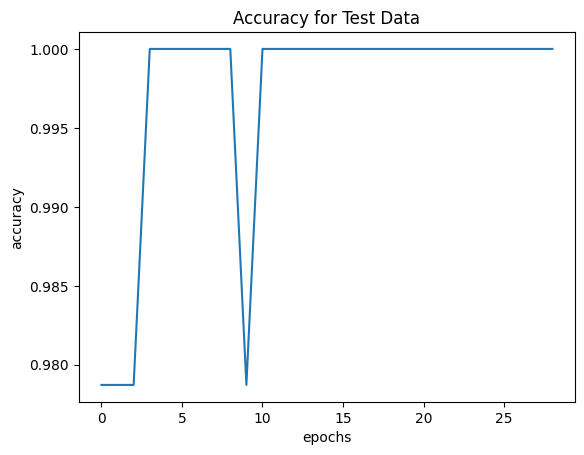

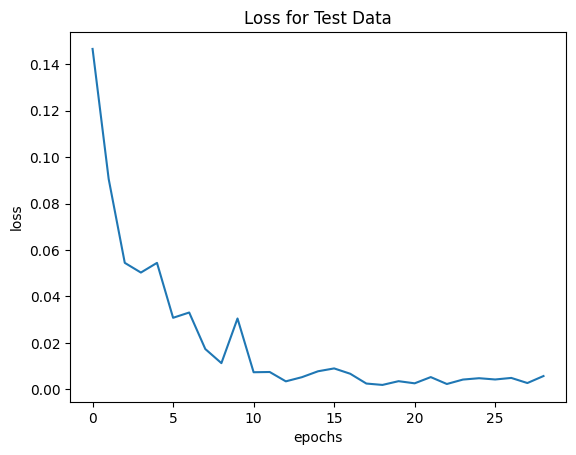

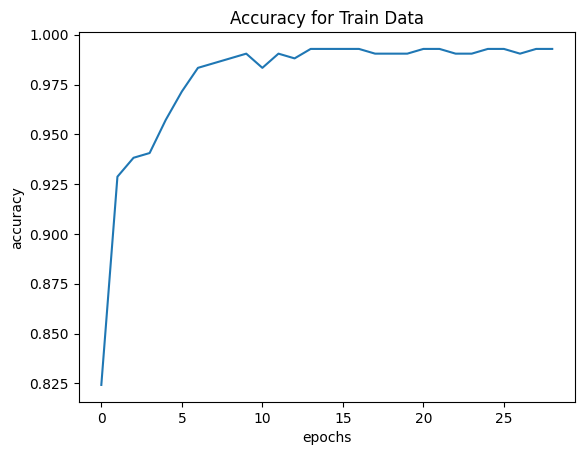

In [72]:
def plot(nn):
    plt.plot(nn.history['val_accuracy'])
    plt.title('Accuracy for Test Data')
    plt.ylabel('accuracy')
    plt.xlabel('epochs')
    plt.show()

    plt.plot(nn.history['val_loss'])
    plt.title('Loss for Test Data')
    plt.ylabel('loss')
    plt.xlabel('epochs')
    plt.show()

    plt.plot(nn.history['accuracy'])
    plt.title('Accuracy for Train Data')
    plt.ylabel('accuracy')
    plt.xlabel('epochs')
    plt.show()

plot(history)

In [73]:
metric = model.evaluate(x_test, y_test)
print(f"Accuracy: {metric[1]}")
print(f"Precision: {metric[2]}")
print(f"Recall: {metric[3]}")
print(f"AUC: {metric[4]}")
print(f"Loss: {metric[0]}")

2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - AUC: 1.0000 - accuracy: 1.0000 - loss: 0.0026 - precision: 1.0000 - recall: 1.0000 
Accuracy: 1.0
Precision: 1.0
Recall: 1.0
AUC: 1.0
Loss: 0.0031570938881486654


17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step


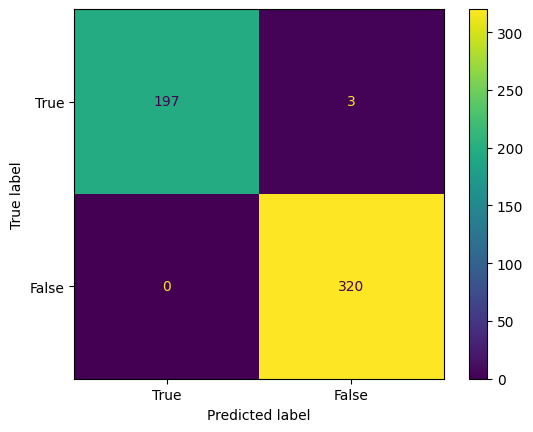

              precision    recall  f1-score   support

           0       1.00      0.98      0.99       200
           1       0.99      1.00      1.00       320

    accuracy                           0.99       520
   macro avg       1.00      0.99      0.99       520
weighted avg       0.99      0.99      0.99       520



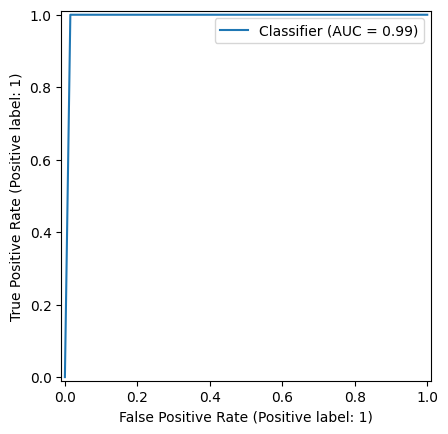

In [74]:
preds = model.predict(X)
preds = np.round(preds)
cm=metrics.confusion_matrix(target,preds)
cm_display = metrics.ConfusionMatrixDisplay(confusion_matrix = cm, display_labels = [True, False])
cm_display.plot()
plt.show()
print(metrics.classification_report(target,preds))
metrics.RocCurveDisplay.from_predictions(
    target, preds,
)
plt.legend()
plt.show()

In [75]:
model.save('diabetes_model.keras')